In [19]:
import pandas as pd
datapath_datos_preprocesados="./Datos/dataframe_preprocesado_campos_completos_ventas_2024_2026.csv"
df=pd.read_csv(datapath_datos_preprocesados,
               sep=";")
df.head(5)

,codigo_articulo,descripcion_completa,grupo_articulo,categoria,subcategoria,tipo,unidad_medida_inventario,marca_fabricante,ultima_fecha_compra,ultimo_precio_compra,...,cantidad_sugerida_pedir,meses_hasta_reorden,decision_compra,valor_venta_mensual_24m,deficit_punto_reorden,deficit_punto_reorden_positivo,monto_riesgo_inmediato,monto_riesgo_proximo,score_prioridad_articulo,venta_mensual_en_revision
0,US2: QF120A,Interruptor 20 A 1P 120 V 10K QPF2 GFCI 5MA,EQUI.AUTO.Y CONTROL,EQUIPO ELECTRICO & AUTOMATIZACION,CENTROS DE CARGA E INTERRUPTORES,NaN,UNI,SIEMENS,2026-06-26 00:00:00,32.680000,...,0.0,1.756959,Evaluar compra - próximo a punto de reorden,20634.356250,-8.217442e+02,0.0,0.0,46283.713583,46283.713583,20634.35625
1,W8,"Cinta para husos, Habasit, W-8",FAJAS,BANDAS,CORREAS PLANAS DE TRANSMISION,CORREAS PLANAS DE TRANSMISION,CM2,HABASIT ROCUA,2026-01-31 00:00:00,0.007366,...,0.0,6.776236,No comprar todavía,2476.004819,-1.687231e+06,0.0,0.0,0.000000,0.000000,0.00000
2,"B-VTOP-CN40-30""",COTTON 40 LB/PI,FAJAS,BANDAS,SERVICIO PESADO,SERVICIO PESADO,CM2,BELTSERVICE,2026-03-13 00:00:00,0.013582,...,0.0,17.596977,No comprar - sobreinventario,2351.675205,-2.256929e+06,0.0,0.0,0.000000,0.000000,0.00000
3,RB330-3PLY-30''-SHRD,"Banda de Hule y lona de 30""",FAJAS,CORREAS,REDONDAS,REDONDAS,MT,SHARDA,2026-02-27 00:00:00,19.335359,...,0.0,2.488219,No comprar - sobreinventario,2238.766294,-2.134083e+02,0.0,0.0,3384.525384,3384.525384,0.00000
4,2.0HP18RB-S-ODP,"Motor monofasico Nema, Potencia 2.0 HP, Voltaj...",MOTORES ELECTRICOS,MOTORES ELECTRICOS,AC MOTORES - NEMA,GENERAL PURPOSE,UNI,MARATHON,2026-06-26 00:00:00,121.692299,...,0.0,10.418882,No comprar - sobreinventario,2265.758492,-1.436937e+02,0.0,0.0,0.000000,0.000000,0.00000


# Clasificación de Artículos Elegibles para Forecast

## Objetivo del apartado

En esta etapa del notebook se define una regla inicial para clasificar qué artículos cuentan con suficiente información histórica para aplicar modelos de predicción de demanda y cuáles deben ser excluidos del proceso de forecast automático.

El objetivo principal es evitar aplicar algoritmos de predicción sobre artículos con muy pocas ventas, demanda extremadamente esporádica o comportamiento insuficiente para construir una señal estadística confiable.

---

## Contexto del problema

Dentro del inventario existen artículos con comportamientos de venta muy diferentes. Algunos artículos presentan ventas frecuentes y recurrentes durante los últimos 24 meses, mientras que otros solamente registran una o dos ventas aisladas en el mismo período.

Aplicar modelos de forecast a todos los artículos por igual puede generar resultados poco confiables, especialmente en productos con baja frecuencia de venta o demanda intermitente extrema.

Por esta razón, antes de realizar clusterización o selección de modelos predictivos, se establece una etapa previa de clasificación de elegibilidad.

---

## Pregunta que responde esta etapa

Esta sección busca responder:

```text
¿Este artículo tiene suficiente historial de demanda para aplicar un modelo de forecast?

In [20]:
import numpy as np
import pandas as pd
import unicodedata

# ============================================================
# CLASIFICACIÓN DINÁMICA DE ARTÍCULOS QUE APLICAN A FORECAST
# ============================================================
# Este bloque evita depender de una columna fija como venta_junio_2026.
# Detecta automáticamente las columnas mensuales de venta y toma los
# últimos 24 meses disponibles para evaluar si aplica forecast.
# ============================================================


# ============================================================
# 1. FUNCIÓN AUXILIAR PARA NORMALIZAR NOMBRES DE MESES
# ============================================================

def quitar_acentos(texto):
    texto = str(texto)
    return ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )


# ============================================================
# 2. MAPEO DE MESES EN ESPAÑOL
# ============================================================

mapa_meses = {
    "enero": 1,
    "febrero": 2,
    "marzo": 3,
    "abril": 4,
    "mayo": 5,
    "junio": 6,
    "julio": 7,
    "agosto": 8,
    "septiembre": 9,
    "setiembre": 9,
    "octubre": 10,
    "noviembre": 11,
    "diciembre": 12
}


# ============================================================
# 3. DETECTAR COLUMNAS DE VENTA MENSUAL
# ============================================================
# Detecta columnas con estructura tipo:
# venta_enero_2024
# venta_febrero_2025
# venta_junio_2026
# ============================================================

columnas_venta_mensual = []

for col in df.columns:
    col_norm = quitar_acentos(col.lower().strip())
    
    if col_norm.startswith("venta_"):
        partes = col_norm.split("_")
        
        if len(partes) == 3:
            _, mes_texto, anio_texto = partes
            
            if mes_texto in mapa_meses and anio_texto.isdigit():
                fecha_columna = pd.Timestamp(
                    year=int(anio_texto),
                    month=mapa_meses[mes_texto],
                    day=1
                )
                
                columnas_venta_mensual.append((col, fecha_columna))


# ============================================================
# 4. ORDENAR COLUMNAS POR FECHA Y TOMAR ÚLTIMOS 24 MESES
# ============================================================

columnas_venta_mensual = sorted(
    columnas_venta_mensual,
    key=lambda x: x[1]
)

columnas_ultimos_24m = [
    col for col, fecha in columnas_venta_mensual[-24:]
]

fecha_inicio_ventana_24m = columnas_venta_mensual[-24][1]
fecha_fin_ventana_24m = columnas_venta_mensual[-1][1]

print(f"Ventana de análisis 24M: {fecha_inicio_ventana_24m.date()} a {fecha_fin_ventana_24m.date()}")
print(f"Columnas consideradas: {len(columnas_ultimos_24m)}")


# ============================================================
# 5. ASEGURAR QUE LAS COLUMNAS DE VENTA SEAN NUMÉRICAS
# ============================================================

for col in columnas_ultimos_24m:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    ).fillna(0)


import numpy as np
import pandas as pd

# ============================================================
# CLASIFICACIÓN DE ARTÍCULOS QUE APLICAN A FORECAST
# ============================================================
# Objetivo:
# Definir si un artículo tiene suficiente historial de demanda
# para entrar a una etapa posterior de clustering y forecast.
#
# Nota:
# Las métricas de últimos 24 meses ya vienen calculadas desde
# el query/base de datos, por lo que no se recalculan aquí.
# ============================================================


# ============================================================
# 6. ASEGURAR COLUMNAS NUMÉRICAS NECESARIAS
# ============================================================

columnas_numericas_forecast = [
    "total_unidades_vendidas_24m",
    "venta_promedio_mensual_24m",
    "meses_con_venta_24m",
    "frecuencia_venta_24m_pct",
    "conteo_facturas_24m",
    "alcance_inventario_24m"
]

for col in columnas_numericas_forecast:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    ).fillna(0)


# ============================================================
# 7. CALCULAR VENTA RECIENTE DINÁMICA
# ============================================================
# En vez de usar fijo venta_enero_2026 a venta_junio_2026,
# se toman automáticamente los últimos 6 meses disponibles.
# ============================================================

columnas_ultimos_6m = columnas_ultimos_24m[-6:]

df["venta_promedio_reciente_last_6m"] = (
    df[columnas_ultimos_6m].sum(axis=1)/6
)

df["ratio_venta_reciente_6m"] = np.where(
    df["total_unidades_vendidas_24m"] > 0,
    df["venta_promedio_reciente_last_6m"] / df["venta_promedio_mensual_24m"],
    0
)



# ============================================================
# 2. DEFINIR UMBRALES DE ELEGIBILIDAD
# ============================================================

umbral_meses_con_venta = 6
umbral_frecuencia_venta_pct = 25
#umbral_conteo_facturas = 6
umbral_venta_promedio_mensual = 0.5

# Umbral máximo de alcance para que valga la pena forecast
# con objetivo de reabastecimiento.
# Ejemplo: si tiene más de 36 meses de inventario, aunque venda,
# no es prioritario aplicar forecast para compra.
umbral_alcance_maximo_forecast_meses = 12


# ============================================================
# 3. CONDICIONES DE ELEGIBILIDAD
# ============================================================

condicion_tiene_venta_24m = (
    df["total_unidades_vendidas_24m"] > 0
)

condicion_meses_suficientes = (
    df["meses_con_venta_24m"] >= umbral_meses_con_venta
)

condicion_frecuencia_suficiente = (
    df["frecuencia_venta_24m_pct"] >= umbral_frecuencia_venta_pct
)

# condicion_facturas_suficientes = (
#     df["conteo_facturas_24m"] >= umbral_conteo_facturas
# )

condicion_venta_promedio_suficiente = (
    df["venta_promedio_mensual_24m"] >= umbral_venta_promedio_mensual
)

condicion_alcance_controlado = (
    df["alcance_inventario_24m"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(9999)
    <= umbral_alcance_maximo_forecast_meses
)

condicion_no_infinito = (
    df["clasificacion_alcance_inventario_24m"]
    .fillna("")
    .ne("Infinito")
)


# ============================================================
# 4. CLASIFICAR SI APLICA FORECAST
# ============================================================

df["aplica_forecast"] = (
    condicion_tiene_venta_24m
    & condicion_meses_suficientes
    & condicion_frecuencia_suficiente
    & condicion_venta_promedio_suficiente
    & condicion_alcance_controlado
    & condicion_no_infinito
)


# ============================================================
# 5. MOTIVO DE CLASIFICACIÓN
# ============================================================
# Esta columna permite auditar por qué un artículo no aplica
# a forecast.
# ============================================================

df["motivo_aplica_forecast"] = np.select(
    [
        df["total_unidades_vendidas_24m"] == 0,

        df["meses_con_venta_24m"] < umbral_meses_con_venta,

        df["frecuencia_venta_24m_pct"] < umbral_frecuencia_venta_pct,

        # df_OITM_Ventas["conteo_facturas_24m"] < umbral_conteo_facturas,

        df["venta_promedio_mensual_24m"] < umbral_venta_promedio_mensual,

        (
            df["alcance_inventario_24m"]
            .replace([np.inf, -np.inf], np.nan)
            .fillna(9999)
            > umbral_alcance_maximo_forecast_meses
        ),

        df["clasificacion_alcance_inventario_24m"]
        .fillna("")
        .eq("Infinito"),

        df["clasificacion_alcance_inventario_24m"]
        .fillna("")
        .eq("Infinito nuevo"),

        df["aplica_forecast"] == True
    ],
    [
        "No aplica - sin ventas en 24M",
        "No aplica - pocos meses con venta",
        "No aplica - baja frecuencia de venta",
        # "No aplica - pocas facturas",
        "No aplica - venta promedio mensual muy baja",
        "No aplica - alcance de inventario excesivo",
        "No aplica - alcance infinito sin demanda",
        "No aplica - alcance infinito nuevo",
        "Aplica forecast"
    ],
    default="Revisar"
)
# )


# 

# # ============================================================
# # 8. ASEGURAR COLUMNAS COMPLEMENTARIAS
# # ============================================================

# columnas_complementarias = [
#     "conteo_facturas_24m",
#     "alcance_inventario_24m"
# ]

# for col in columnas_complementarias:
#     if col in df_OITM_Ventas.columns:
#         df_OITM_Ventas[col] = pd.to_numeric(
#             df_OITM_Ventas[col],
#             errors="coerce"
#         )


# # ============================================================
# # 9. DEFINIR UMBRALES DE ELEGIBILIDAD
# # ============================================================

# umbral_meses_con_venta = 6
# umbral_frecuencia_venta_pct = 25
# umbral_conteo_facturas = 6
# umbral_venta_promedio_mensual = 0.10
# umbral_ratio_venta_reciente = 0.05

# # Umbral de alcance máximo para considerar forecast útil.
# # Si el artículo tiene demasiado inventario para su demanda,
# # puede no ser prioritario aplicar forecast para reposición.
# umbral_alcance_maximo_forecast_meses = 36


# # ============================================================
# # 10. CONDICIONES DE ELEGIBILIDAD
# # ============================================================

# condicion_tiene_venta_24m = (
#     df_OITM_Ventas["venta_total_ventana_24m"] > 0
# )

# condicion_meses_suficientes = (
#     df_OITM_Ventas["meses_con_venta_ventana_24m"] >= umbral_meses_con_venta
# )

# condicion_frecuencia_suficiente = (
#     df_OITM_Ventas["frecuencia_venta_ventana_24m_pct"] >= umbral_frecuencia_venta_pct
# )

# condicion_facturas_suficientes = (
#     df_OITM_Ventas["conteo_facturas_24m"].fillna(0) >= umbral_conteo_facturas
# )

# condicion_venta_promedio_suficiente = (
#     df_OITM_Ventas["venta_promedio_mensual_ventana_24m"] >= umbral_venta_promedio_mensual
# )

# condicion_demanda_reciente = (
#     df_OITM_Ventas["ratio_venta_reciente_6m"] >= umbral_ratio_venta_reciente
# )

# condicion_alcance_controlado = (
#     df_OITM_Ventas["alcance_inventario_24m"].replace([np.inf, -np.inf], np.nan).fillna(9999)
#     <= umbral_alcance_maximo_forecast_meses
# )

# condicion_no_infinito = (
#     df_OITM_Ventas["clasificacion_alcance_inventario_24m"]
#     .fillna("")
#     .ne("Infinito")
# )


# # ============================================================
# # 11. CLASIFICAR SI APLICA FORECAST
# # ============================================================

# df_OITM_Ventas["aplica_forecast"] = (
#     condicion_tiene_venta_24m
#     & condicion_meses_suficientes
#     & condicion_frecuencia_suficiente
#     & condicion_facturas_suficientes
#     & condicion_venta_promedio_suficiente
#     & condicion_demanda_reciente
#     & condicion_alcance_controlado
#     & condicion_no_infinito
# )


# # ============================================================
# # 12. MOTIVO DE CLASIFICACIÓN
# # ============================================================

# df_OITM_Ventas["motivo_aplica_forecast"] = np.select(
#     [
#         df_OITM_Ventas["venta_total_ventana_24m"] == 0,

#         df_OITM_Ventas["meses_con_venta_ventana_24m"] < umbral_meses_con_venta,

#         df_OITM_Ventas["frecuencia_venta_ventana_24m_pct"] < umbral_frecuencia_venta_pct,

#         df_OITM_Ventas["conteo_facturas_24m"].fillna(0) < umbral_conteo_facturas,

#         df_OITM_Ventas["venta_promedio_mensual_ventana_24m"] < umbral_venta_promedio_mensual,

#         df_OITM_Ventas["ratio_venta_reciente_6m"] < umbral_ratio_venta_reciente,

#         (
#             df_OITM_Ventas["alcance_inventario_24m"]
#             .replace([np.inf, -np.inf], np.nan)
#             .fillna(9999)
#             > umbral_alcance_maximo_forecast_meses
#         ),

#         df_OITM_Ventas["clasificacion_alcance_inventario_24m"]
#         .fillna("")
#         .eq("Infinito"),

#         df_OITM_Ventas["aplica_forecast"] == True
#     ],
#     [
#         "No aplica - sin ventas en ventana 24M",
#         "No aplica - pocos meses con venta",
#         "No aplica - baja frecuencia de venta",
#         "No aplica - pocas facturas",
#         "No aplica - venta promedio mensual muy baja",
#         "No aplica - sin demanda reciente",
#         "No aplica - alcance de inventario excesivo",
#         "No aplica - alcance infinito sin demanda",
#         "Aplica forecast"
#     ],
#     default="Revisar"
# )

Ventana de análisis 24M: 2024-08-01 a 2026-07-01
Columnas consideradas: 24


C:\Users\CHOPPE\AppData\Local\Temp\ipykernel_22220\2023689663.py:153: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["venta_promedio_reciente_last_6m"] = (
C:\Users\CHOPPE\AppData\Local\Temp\ipykernel_22220\2023689663.py:157: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ratio_venta_reciente_6m"] = np.where(
C:\Users\CHOPPE\AppData\Local\Temp\ipykernel_22220\2023689663.py:240: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  C

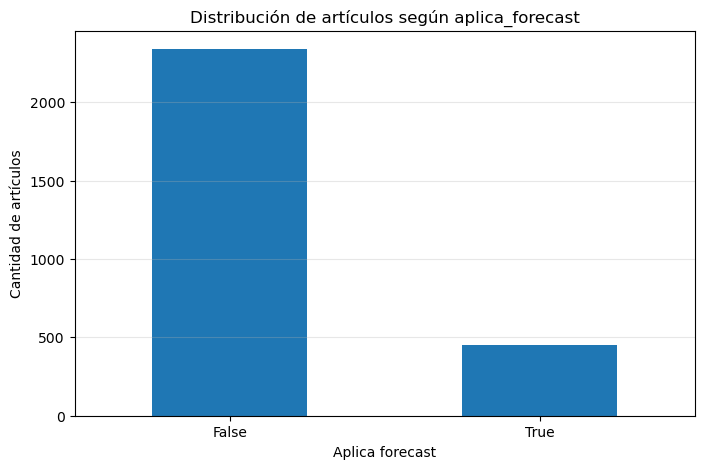

In [21]:
import matplotlib.pyplot as plt

conteo_forecast = df["aplica_forecast"].value_counts(dropna=False)

plt.figure(figsize=(8, 5))
conteo_forecast.plot(kind="bar")

plt.title("Distribución de artículos según aplica_forecast")
plt.xlabel("Aplica forecast")
plt.ylabel("Cantidad de artículos")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [22]:
df["motivo_aplica_forecast"].value_counts(dropna=False)

motivo_aplica_forecast
No aplica - pocos meses con venta              1320
No aplica - sin ventas en 24M                   859
Aplica forecast                                 450
No aplica - alcance de inventario excesivo      129
No aplica - venta promedio mensual muy baja      32
Name: count, dtype: int64

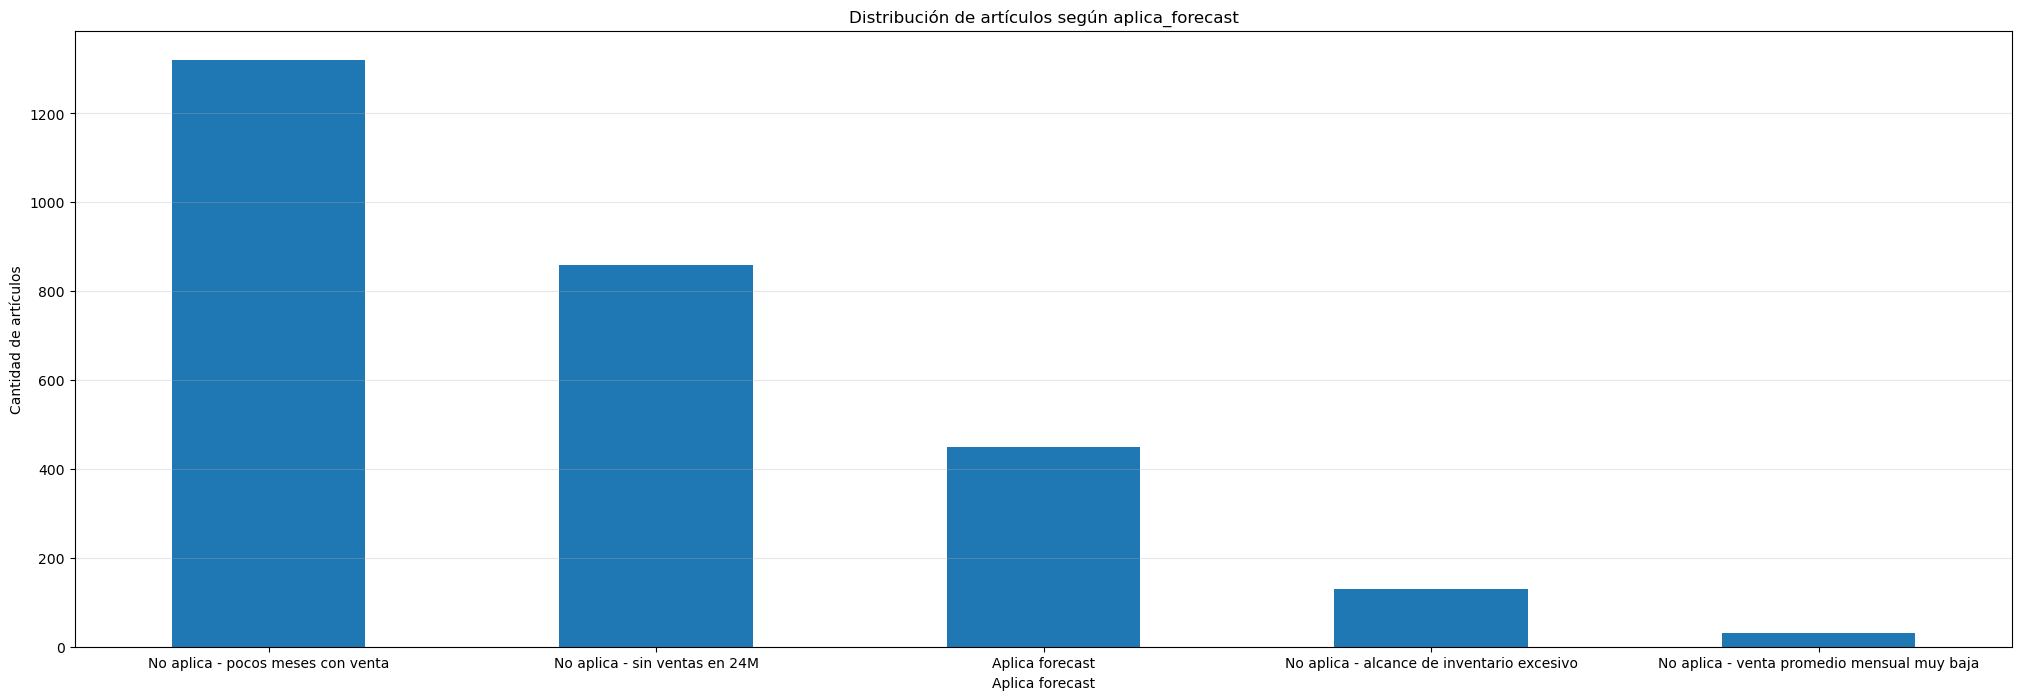

In [23]:
import matplotlib.pyplot as plt

conteo_forecast = df["motivo_aplica_forecast"].value_counts(dropna=False)

plt.figure(figsize=(25, 8))
conteo_forecast.plot(kind="bar")

plt.title("Distribución de artículos según aplica_forecast")
plt.xlabel("Aplica forecast")
plt.ylabel("Cantidad de artículos")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [24]:
df_aplica_forecast=df[df["aplica_forecast"]==True].copy()

In [25]:
df_aplica_forecast.head(-5)

,codigo_articulo,descripcion_completa,grupo_articulo,categoria,subcategoria,tipo,unidad_medida_inventario,marca_fabricante,ultima_fecha_compra,ultimo_precio_compra,...,valor_venta_mensual_24m,deficit_punto_reorden,deficit_punto_reorden_positivo,monto_riesgo_inmediato,monto_riesgo_proximo,score_prioridad_articulo,venta_mensual_en_revision,venta_promedio_reciente_last_6m,ratio_venta_reciente_6m,motivo_aplica_forecast
0,US2: QF120A,Interruptor 20 A 1P 120 V 10K QPF2 GFCI 5MA,EQUI.AUTO.Y CONTROL,EQUIPO ELECTRICO & AUTOMATIZACION,CENTROS DE CARGA E INTERRUPTORES,NaN,UNI,SIEMENS,2026-06-26 00:00:00,32.680000,...,20634.356250,-8.217442e+02,0.000000,0.000000,46283.713583,46283.713583,20634.356250,395.500000,0.845612,Aplica forecast
1,W8,"Cinta para husos, Habasit, W-8",FAJAS,BANDAS,CORREAS PLANAS DE TRANSMISION,CORREAS PLANAS DE TRANSMISION,CM2,HABASIT ROCUA,2026-01-31 00:00:00,0.007366,...,2476.004819,-1.687231e+06,0.000000,0.000000,0.000000,0.000000,0.000000,240040.970000,0.964050,Aplica forecast
3,RB330-3PLY-30''-SHRD,"Banda de Hule y lona de 30""",FAJAS,CORREAS,REDONDAS,REDONDAS,MT,SHARDA,2026-02-27 00:00:00,19.335359,...,2238.766294,-2.134083e+02,0.000000,0.000000,3384.525384,3384.525384,0.000000,43.551667,0.507788,Aplica forecast
9,C3.5-TEH-14.984,RODILLO RETRO PSV/1.20F14.89N.38,POLEAS RODI.Y TAMB.,NaN,NaN,NaN,UNI,PRECISION INC,2026-05-31 00:00:00,51.088667,...,1643.777861,-1.556889e+02,0.000000,0.000000,0.000000,0.000000,0.000000,32.166667,1.349650,Aplica forecast
10,RB330-3PLY-24''-SHRD,"Banda de Hule y lona de 24"" 3 lonas",FAJAS,CORREAS,REDONDAS,REDONDAS,MT,SHARDA,2026-06-01 00:00:00,21.100484,...,1654.161893,2.472802e+02,247.280222,7043.938685,0.000000,7043.938685,1654.161893,71.051667,1.223552,Aplica forecast
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1477,A048,"Correa trapezoidal estandar, A48, Longitud ext...",FAJAS,CORREAS,TRAPEZOIDALES,ESTANDAR,UNI,BANDO,2026-06-30 00:00:00,3.433002,...,2.703489,-1.113889e+00,0.000000,0.000000,5.651580,5.651580,2.703489,0.500000,0.857143,Aplica forecast
1479,B035,"Correa trapezoidal estandar, B35, Longitud ext...",FAJAS,CORREAS,TRAPEZOIDALES,ESTANDAR,UNI,BANDO,2026-04-30 00:00:00,3.665304,...,3.298774,-2.666667e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Aplica forecast
1494,63042RS,"Rodamiento rigido de bolas, 6304LLU, NTN",BALEROS,RODAMIENTOS,BOLAS,RIGIDO DE BOLAS,UNI,NTN,2025-05-23 00:00:00,3.272086,...,2.576768,-1.708333e+00,0.000000,0.000000,2.760823,2.760823,0.000000,1.000000,1.714286,Aplica forecast
1519,6072RSC3,"Rodamiento rigido de bolas, 607LLUC3, NTN",BALEROS,RODAMIENTOS,BOLAS,RIGIDO DE BOLAS,UNI,NTN,2025-05-23 00:00:00,2.126856,...,2.392713,-3.555556e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.333333,0.400000,Aplica forecast


In [26]:
from datetime import datetime

fecha_hoy = datetime.today().strftime("%Y-%m-%d")

nombre_archivo = f"dataframe_aplica_forecast_true_rev_{fecha_hoy}.csv"

print(nombre_archivo)

dataframe_aplica_forecast_true_rev_2026-07-18.csv


In [27]:
ruta=f"./Datos/dataframe_aplica_forecast_true_rev_{fecha_hoy}.csv"
df_aplica_forecast.to_csv(ruta,
    index=False,
    encoding="utf-8-sig",
    sep=";"
)